In [1]:
# Chargement du fihier enrichi
import pandas as pd
df = pd.read_csv("../data/results/avis_with_topics.csv")
df.head()

,avis_clients,avis nettoye,lang,tokens,text_lemmas,longueur,topic_lda,topic_bertopic
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"['spa', 'proposer', 'traitement', 'signatur', ...",spa proposer traitement signatur exclusif deve...,20,3,32
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"['sejour', 'correct', 'justifier', 'pleinement...",sejour correct justifier pleinement classement...,23,0,-1
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"['exposition', 'collection', 'art', 'contempor...",exposition collection art contemporain hotel p...,13,3,-1
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"['emplacement', 'privilegie', 'parfaire', 'exp...",emplacement privilegie parfaire explorer ville...,24,3,16
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"['petit', 'dejeuner', 'buffet', 'varier', 'raf...",petit dejeuner buffet varier raffine reapprovi...,18,3,5


In [2]:
# Nettoyage minimal du texte

# On garde uniquement la colonne brute
df["avis_clean"] = (
    df["avis_clients"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

# Suppression des avis vides
df = df[df["avis_clean"].str.len() > 0].reset_index(drop=True)

df[["avis_clients", "avis_clean"]].head()

,avis_clients,avis_clean
0,Le spa propose un traitement signature exclusi...,Le spa propose un traitement signature exclusi...
1,Un séjour correct mais qui ne justifie pas ple...,Un séjour correct mais qui ne justifie pas ple...
2,The laundry service express saved our gala din...,The laundry service express saved our gala din...
3,L'exposition de collection d'art contemporain ...,L'exposition de collection d'art contemporain ...
4,L'emplacement privilégié est parfait pour expl...,L'emplacement privilégié est parfait pour expl...


In [3]:
# Detection automatique de la langue (FR/EN)
! pip install langdetect
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42  # Pour des résultats reproductibles

def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

df['lang'] = df['avis_clean'].apply(detect_language)
df['lang'].value_counts()

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


lang
en    5035
fr     909
it       1
Name: count, dtype: int64

In [4]:
# Creer une colonne vide pour les scores
df['sentiment_score'] = None
df['sentiment_vader'] = None
df['sentiment_textblob'] = None

In [5]:
# Apercu final avant analyse
df.head()

,avis_clients,avis nettoye,lang,tokens,text_lemmas,longueur,topic_lda,topic_bertopic,avis_clean,sentiment_score,sentiment_vader,sentiment_textblob
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"['spa', 'proposer', 'traitement', 'signatur', ...",spa proposer traitement signatur exclusif deve...,20,3,32,Le spa propose un traitement signature exclusi...,None,None,None
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"['sejour', 'correct', 'justifier', 'pleinement...",sejour correct justifier pleinement classement...,23,0,-1,Un séjour correct mais qui ne justifie pas ple...,None,None,None
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"['exposition', 'collection', 'art', 'contempor...",exposition collection art contemporain hotel p...,13,3,-1,The laundry service express saved our gala din...,None,None,None
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"['emplacement', 'privilegie', 'parfaire', 'exp...",emplacement privilegie parfaire explorer ville...,24,3,16,L'exposition de collection d'art contemporain ...,None,None,None
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"['petit', 'dejeuner', 'buffet', 'varier', 'raf...",petit dejeuner buffet varier raffine reapprovi...,18,3,5,L'emplacement privilégié est parfait pour expl...,None,None,None


Analyse des sentiments avec VADER (anglais)

- Appliquer VADER uniquement aux avis détectés comme anglais
- Obtenir un score de sentiment entre -1 (négatif) et +1 (positif)
- Stocker les résultats dans sentiment_vader




In [7]:
%pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

# Application de VADER uniquement sur les avis en anglais
def vader_score(text):
    return vader.polarity_scores(text)['compound']
df.loc[df['lang'] == 'en', 'sentiment_vader'] = df.loc[df['lang'] == 'en', 'avis_clean'].apply(vader_score)


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Verification rapide
df[df['lang'] == 'en'][['avis_clean', 'sentiment_vader']].head()

,avis_clean,sentiment_vader
2,The laundry service express saved our gala din...,0.4215
6,The staff is polite but seems to follow a rigi...,0.6652
10,Hotel De La Promenade organizes exclusive enco...,0.5106
13,The ballroom with historical significance wher...,0.7269
14,"Hotel De La Promenade is ideally located, but ...",-0.6576


In [9]:
# Categorisation du sentiment
def vader_label(score):
    if score is None:
        return None
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'
df['sentiment_vader_label'] = df['sentiment_vader'].apply(vader_label)

In [12]:
# Apercu
df.head()

,avis_clients,avis nettoye,lang,tokens,text_lemmas,longueur,topic_lda,topic_bertopic,avis_clean,sentiment_score,sentiment_vader,sentiment_textblob,sentiment_vader_label
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"['spa', 'proposer', 'traitement', 'signatur', ...",spa proposer traitement signatur exclusif deve...,20,3,32,Le spa propose un traitement signature exclusi...,None,None,None,None
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"['sejour', 'correct', 'justifier', 'pleinement...",sejour correct justifier pleinement classement...,23,0,-1,Un séjour correct mais qui ne justifie pas ple...,None,None,None,None
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"['exposition', 'collection', 'art', 'contempor...",exposition collection art contemporain hotel p...,13,3,-1,The laundry service express saved our gala din...,None,0.4215,None,positive
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"['emplacement', 'privilegie', 'parfaire', 'exp...",emplacement privilegie parfaire explorer ville...,24,3,16,L'exposition de collection d'art contemporain ...,None,None,None,None
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"['petit', 'dejeuner', 'buffet', 'varier', 'raf...",petit dejeuner buffet varier raffine reapprovi...,18,3,5,L'emplacement privilégié est parfait pour expl...,None,None,None,None


Analyse des sentiments en français (TextBlob FR / Pattern)
- Analyser les avis en français
- Obtenir un score de sentiment entre -1 (négatif) et +1 (positif)
- Stocker les résultats dans sentiment_textblob
- Préparer la fusion avec VADER


In [14]:
%pip install textblob 
%pip install textblob_fr
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer
tb = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

  Using cached textblob-0.19.0-py3-none-any.whl.metadata (4.4 kB)
Using cached textblob-0.19.0-py3-none-any.whl (624 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached textblob_fr-0.2.0-py2.py3-none-any.whl.metadata (4.8 kB)
Using cached textblob_fr-0.2.0-py2.py3-none-any.whl (561 kB)
Note: you may need to restart the kernel to use updated packages.


In [15]:
# Apliquer TextBlob_fr uniquement sur les avis en français

def textblob_fr_score(text):
    try:
        return tb(text).sentiment[0]  # On prend le score de polarité
    except:
        return None
    
df.loc[df['lang'] == 'fr', 'sentiment_textblob'] = df.loc[df['lang'] == 'fr', 'avis_clean'].apply(textblob_fr_score)

# Verification rapide
df[df['lang'] == 'fr'][['avis_clean', 'sentiment_textblob']].head()

,avis_clean,sentiment_textblob
0,Le spa propose un traitement signature exclusi...,-0.015
1,Un séjour correct mais qui ne justifie pas ple...,0.216667
3,L'exposition de collection d'art contemporain ...,0.2725
4,L'emplacement privilégié est parfait pour expl...,0.3125
5,Le petit-déjeuner buffet est varié et raffiné....,0.03


In [17]:
# Categoriation du sentiment pour TextBlob_fr

def textblob_fr_label(score):
    if score is None:
        return None
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'
    
df['sentiment_textblob_label'] = df['sentiment_textblob'].apply(textblob_fr_label)

In [18]:
# Apercu final
df.head()

,avis_clients,avis nettoye,lang,tokens,text_lemmas,longueur,topic_lda,topic_bertopic,avis_clean,sentiment_score,sentiment_vader,sentiment_textblob,sentiment_vader_label,sentiment_textblob_label
0,Le spa propose un traitement signature exclusi...,le spa propose un traitement signature exclusi...,fr,"['spa', 'proposer', 'traitement', 'signatur', ...",spa proposer traitement signatur exclusif deve...,20,3,32,Le spa propose un traitement signature exclusi...,None,None,-0.015,None,neutral
1,Un séjour correct mais qui ne justifie pas ple...,un sejour correct mais qui ne justifie pas ple...,fr,"['sejour', 'correct', 'justifier', 'pleinement...",sejour correct justifier pleinement classement...,23,0,-1,Un séjour correct mais qui ne justifie pas ple...,None,None,0.216667,None,positive
2,The laundry service express saved our gala din...,the laundry service express saved our gala din...,en,"['exposition', 'collection', 'art', 'contempor...",exposition collection art contemporain hotel p...,13,3,-1,The laundry service express saved our gala din...,None,0.4215,None,positive,None
3,L'exposition de collection d'art contemporain ...,l'exposition de collection d'art contemporain ...,fr,"['emplacement', 'privilegie', 'parfaire', 'exp...",emplacement privilegie parfaire explorer ville...,24,3,16,L'exposition de collection d'art contemporain ...,None,None,0.2725,None,positive
4,L'emplacement privilégié est parfait pour expl...,l'emplacement privilegie est parfait pour expl...,fr,"['petit', 'dejeuner', 'buffet', 'varier', 'raf...",petit dejeuner buffet varier raffine reapprovi...,18,3,5,L'emplacement privilégié est parfait pour expl...,None,None,0.3125,None,positive


Fusion des scores FR/EN

- Combiner les scores VADER (anglais) et TextBlob FR (français)
- Produire une seule colonne : sentiment_score
- Produire une étiquette finale : sentiment_label
- Gérer les cas particuliers (unknown, avis très courts, erreurs)


In [19]:
# Fusion simple

def fusion_score(row):
    if row['lang'] == 'en':
        return row['sentiment_vader']
    elif row['lang'] == 'fr':
        return row['sentiment_textblob']
    else:
        return None
df['sentiment_score'] = df.apply(fusion_score, axis=1)

In [20]:
# Categorisation finale

def final_label(score):
    if score is None:
        return None
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'
df['sentiment_label'] = df['sentiment_score'].apply(final_label)

In [21]:
# Verification rapide
df[['avis_clean', 'lang', 'sentiment_vader', 'sentiment_textblob', 'sentiment_score', 'sentiment_label']].head()

,avis_clean,lang,sentiment_vader,sentiment_textblob,sentiment_score,sentiment_label
0,Le spa propose un traitement signature exclusi...,fr,None,-0.015,-0.015000,neutral
1,Un séjour correct mais qui ne justifie pas ple...,fr,None,0.216667,0.216667,positive
2,The laundry service express saved our gala din...,en,0.4215,None,0.421500,positive
3,L'exposition de collection d'art contemporain ...,fr,None,0.2725,0.272500,positive
4,L'emplacement privilégié est parfait pour expl...,fr,None,0.3125,0.312500,positive


In [22]:
# Distribution des sentiments
df['sentiment_label'].value_counts()

sentiment_label
positive    5226
negative     518
neutral      201
Name: count, dtype: int64

Visualisation des sentiments

Créer des graphiques qui montrent :
- comment les avis se répartissent émotionnellement
- quels topics sont les plus positifs ou négatifs
- la tonalité générale du corpus


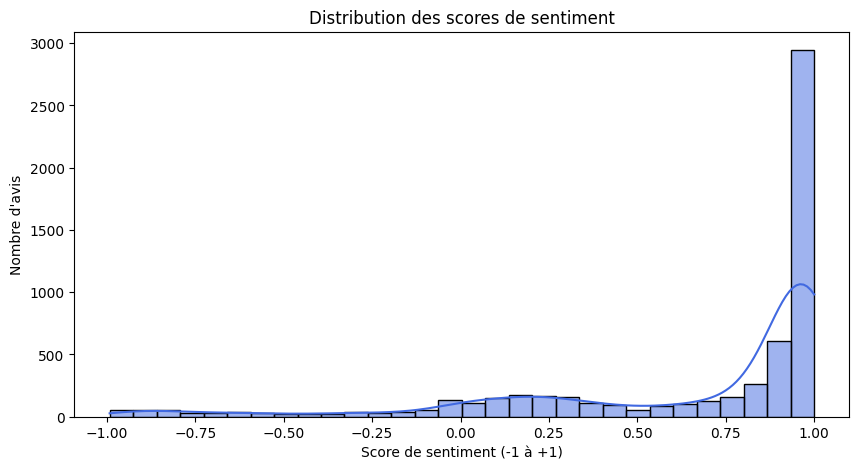

In [ ]:
# Distribution des scores de sentiment
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df["sentiment_score"].dropna(), kde=True, bins=30, color="royalblue")
plt.title("Distribution des scores de sentiment")
plt.xlabel("Score de sentiment (-1 à +1)")
plt.ylabel("Nombre d'avis")
plt.show()

C:\Users\IBRAHIM TRAORE\AppData\Local\Temp\ipykernel_29004\4178540224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["sentiment_label"], palette="viridis")


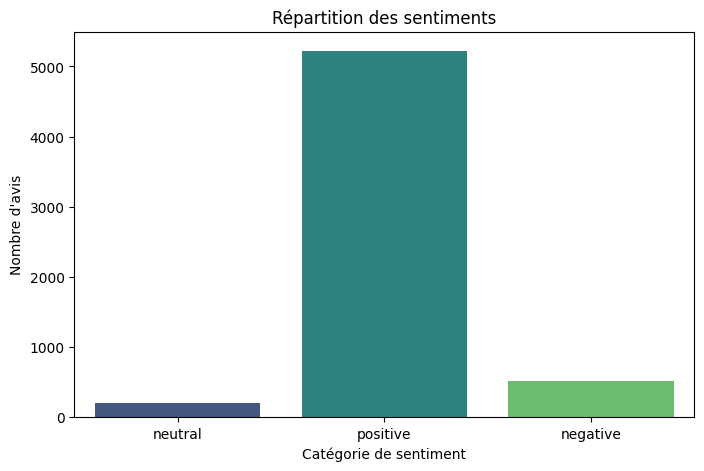

In [24]:
# Repartition positif/neutre/negatif
plt.figure(figsize=(8,5))
sns.countplot(x=df["sentiment_label"], palette="viridis")
plt.title("Répartition des sentiments")
plt.xlabel("Catégorie de sentiment")
plt.ylabel("Nombre d'avis")
plt.show()

C:\Users\IBRAHIM TRAORE\AppData\Local\Temp\ipykernel_29004\1899644737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bertopic_sentiment.index, y=bertopic_sentiment.values, palette="coolwarm")


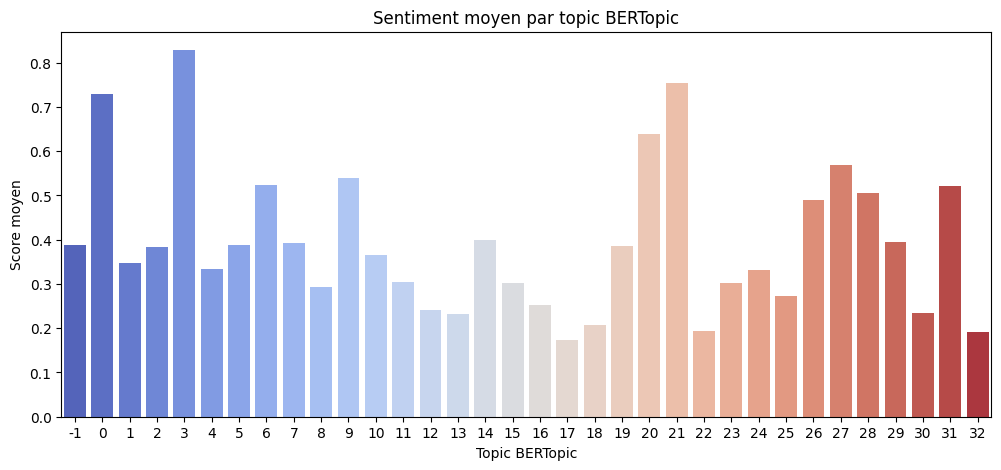

In [25]:
# Sentiment moyen par topic
bertopic_sentiment = df.groupby("topic_bertopic")["sentiment_score"].mean()

plt.figure(figsize=(12,5))
sns.barplot(x=bertopic_sentiment.index, y=bertopic_sentiment.values, palette="coolwarm")
plt.title("Sentiment moyen par topic BERTopic")
plt.xlabel("Topic BERTopic")
plt.ylabel("Score moyen")
plt.show()

# 1. Interprétation des résultats

Cette section interprète les scores de sentiment en lien direct avec les thèmes identifiés par BERTopic.  
L’objectif est de comprendre ce que les clients apprécient réellement, ce qui les déçoit, et quels aspects influencent le plus leur satisfaction.

---

## 1.1 Sentiment global des avis

L’analyse des sentiments montre une tonalité **globalement très positive**.  
Le topic dominant (Topic 0), qui regroupe **4 778 avis**, contient des commentaires très favorables sur :

- la propreté  
- la sécurité  
- la localisation  
- le personnel  
- le confort général  

Ce cluster massif tire la moyenne générale vers le haut et constitue le cœur de l’expérience client.

---

## 1.2 Points forts identifiés (clusters positifs)

Plusieurs topics montrent une satisfaction élevée et constante :

### ** Topic 0 — Avis généraux très positifs (4 778 avis)**  
Les clients soulignent :  
- un hôtel propre  
- un personnel accueillant  
- une localisation idéale  
- un séjour agréable  
C’est le pilier de la réputation de l’hôtel.

### ** Topic 1 — Séjour agréable & chambre correcte (288 avis)**  
Les avis mentionnent :  
- un bon rapport qualité-prix  
- une chambre confortable  
- un petit déjeuner apprécié  

### ** Topic 4 — Chambres spacieuses et élégantes (33 avis)**  
Les clients valorisent :  
- l’espace  
- la décoration  
- le confort visuel  

### ** Topic 7 — Restaurant gastronomique (27 avis)**  
Les retours sont très positifs sur :  
- la qualité de la cuisine  
- la créativité des plats  
- l’expérience culinaire  

### ** Topic 8 — Spa luxueux (26 avis)**  
Les avis évoquent :  
- des soins de qualité  
- un cadre relaxant  
- des thérapeutes professionnels  

### ** Topic 16 — Emplacement idéal (17 avis)**  
Les clients apprécient :  
- la proximité du centre  
- l’accès facile aux attractions  
- les services de navette  

### ** Topic 25 — Personnel attentif et professionnel (13 avis)**  
Les retours mettent en avant :  
- l’écoute  
- la disponibilité  
- le professionnalisme  

Ces clusters confirment que **le personnel, la propreté, la localisation et les services premium** sont les principaux moteurs de satisfaction.

---

##  Points faibles identifiés (clusters négatifs)

Certains topics révèlent des problèmes récurrents ou des expériences négatives :

### ** Topic -1 — Chambre vétuste & service décevant (275 avis)**  
Les clients se plaignent de :  
- chambres vieillissantes  
- équipements défectueux  
- photos trompeuses  
- service insuffisant  

### ** Topic 14 — Hygiène inacceptable (19 avis)**  
Les avis mentionnent :  
- draps tachés  
- moisissures  
- salle de bain mal nettoyée  
C’est un cluster critique, car il touche à la propreté.

### ** Topic 15 — Mauvaise insonorisation (18 avis)**  
Les clients évoquent :  
- bruit dans les couloirs  
- mauvaise isolation  
- promesses non tenues  

### ** Topic 17 — Chambre attribuée ≠ chambre réservée (17 avis)**  
Les avis parlent de :  
- déception  
- mauvaise gestion des réservations  
- incohérence entre photos et réalité  

### ** Topic 18 — Service inattentif / condescendant (17 avis)**  
Les clients décrivent :  
- un personnel peu à l’écoute  
- des demandes ignorées  
- une attitude froide  

### ** Topic 29 — Rapport qualité-prix défavorable (12 avis)**  
Les avis indiquent :  
- prix trop élevés  
- prestations jugées insuffisantes  

### ** Topic 30 — Mauvaise gestion des plaintes (11 avis)**  
Les clients évoquent :  
- un personnel méprisant  
- des plaintes non traitées  
- un manque de considération  

Ces clusters négatifs sont moins nombreux, mais ils touchent des aspects sensibles :  
**propreté, service, bruit, prix, gestion des plaintes**.

---

##  Expériences premium (clusters spécialisés)

Certains topics décrivent des expériences haut de gamme, très appréciées :

- **Topic 2 : dégustation / sommelier**  
- **Topic 3 : terrasse privée / vue panoramique**  
- **Topic 9 : service limousine**  
- **Topic 20 : menu dégustation / chef**  
- **Topic 27 : expériences culturelles exclusives**  

Ces services contribuent à l’image d’un hôtel **haut de gamme**, avec une offre diversifiée.

---

##  Synthèse générale

L’analyse croisée des sentiments et des topics montre que :

### **Points forts majeurs**
- Propreté (sauf exceptions du Topic 14)  
- Personnel (Topics 0 et 25)  
- Localisation (Topic 16)  
- Confort des chambres (Topics 1, 4, 6)  
- Services premium (spa, restaurant, dégustation, terrasse)  

### **Points faibles à corriger**
- Hygiène dans certaines chambres  
- Insonorisation  
- Gestion des réservations  
- Attitude du personnel dans certains cas  
- Rapport qualité-prix perçu comme élevé  
- Gestion des plaintes  

---

## Conclusion

L’hôtel bénéficie d’une **image globalement très positive**, soutenue par un grand volume d’avis favorables.  
Les clients apprécient particulièrement :

- la propreté  
- le personnel  
- la localisation  
- les services premium  

Les points négatifs, bien que minoritaires, concernent des aspects critiques (hygiène, bruit, service) et doivent être traités en priorité pour maintenir un haut niveau de satisfaction.